# Outlier

-> Data outside of the range

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:

dataset = pd.read_csv(r"C:\Users\SHAMSHER\Downloads\student-lifestyle-and-stress-dataset.csv")
dataset.head(3)


,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1


In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_Type        24248 non-null  object 
 1   Sleep_Hours         24167 non-null  float64
 2   Study_Hours         24223 non-null  float64
 3   Social_Media_Hours  24188 non-null  float64
 4   Attendance          24195 non-null  float64
 5   Exam_Pressure       24230 non-null  float64
 6   Family_Support      24209 non-null  float64
 7   Month               24186 non-null  float64
 8   Stress_Level        25500 non-null  int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 1.8+ MB


In [11]:
dataset.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,24223.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.696477,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.240148,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,3.078230,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.538138,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.135670,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


In [16]:
dataset.isnull().sum()

Student_Type          1252
Sleep_Hours           1333
Study_Hours              0
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

In [15]:
dataset["Study_Hours"].fillna(dataset["Study_Hours"].mode()[0],inplace=True)

C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_23244\2777537497.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset["Study_Hours"].fillna(dataset["Study_Hours"].mode()[0],inplace=True)


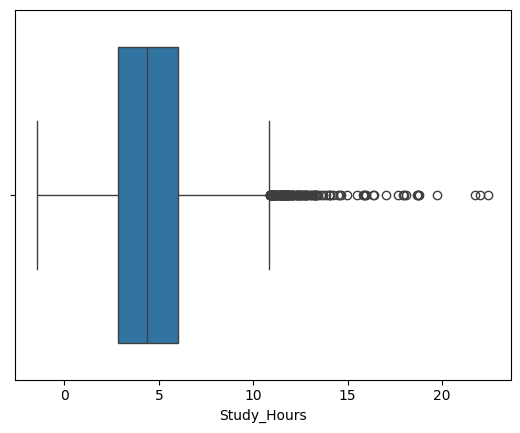

In [19]:
sns.boxplot(x = "Study_Hours",data = dataset)
plt.show()

C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_23244\1043130806.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["Study_Hours"])


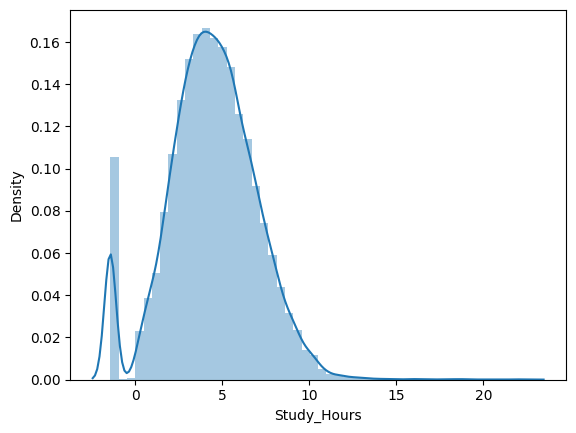

In [20]:
sns.distplot(dataset["Study_Hours"])
plt.show()

Long Tail -> outliers

In [21]:
l = [4,5,6,7,5,3,5,6]
sum(l)/len(l) # Mean

5.125

In [ ]:
l = [4,5,6,7,5,3,5,6,99] # 99 -> Outlier , giving wrong mean
sum(l)/len(l) # Mean

15.555555555555555

# Remove an Outlier

Two Methods -> Using IQR and Z-Score Method

## Using IQR 

In [24]:
dataset.head(3)

,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1


In [ ]:
dataset.isnull().sum()

Student_Type          1252
Sleep_Hours           1333
Study_Hours              0
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

In [26]:
dataset.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,25500.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.389501,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.560179,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,2.820657,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.382555,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.034491,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


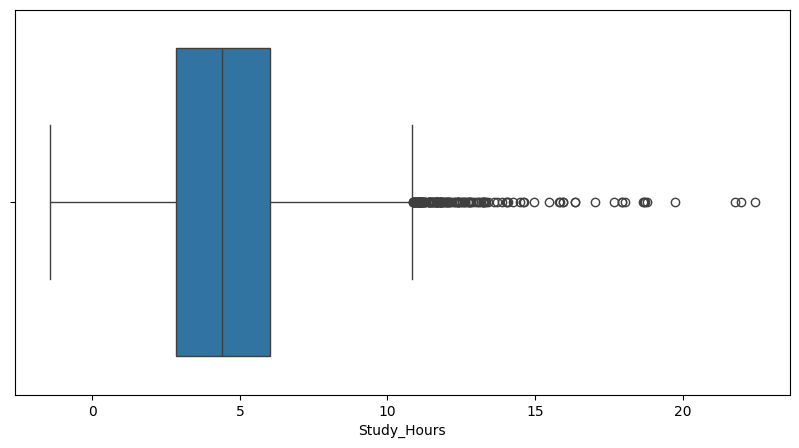

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Study_Hours",data=dataset)
plt.show()

Remove Outliers 
IQR - Inter Quantile Range = Q3 - Q1
min ------ Q1 Median Q3 --------max
          |            |
           ------------
              IQR
min = Q1-(1.5 x IQR)
max = Q1 + (1.5 x IQR)

In [30]:
dataset.shape

(25500, 9)

In [34]:
q1 = dataset["Study_Hours"].quantile(0.25)
q3 = dataset["Study_Hours"].quantile(0.75)
print(q1)
q3



2.820657379162829


np.float64(6.034491454108135)

In [35]:
IQR = q3-q1
IQR

np.float64(3.2138340749453063)

In [38]:
min_range = q1-(1.5 * IQR)
max_range = q3 + (1.5 * IQR)
print(min_range)
print(max_range)

-2.00009373325513
10.855242566526094


In [40]:
new_dataset = dataset[dataset["Study_Hours"]<=max_range]

In [42]:
new_dataset.shape

(25353, 9)

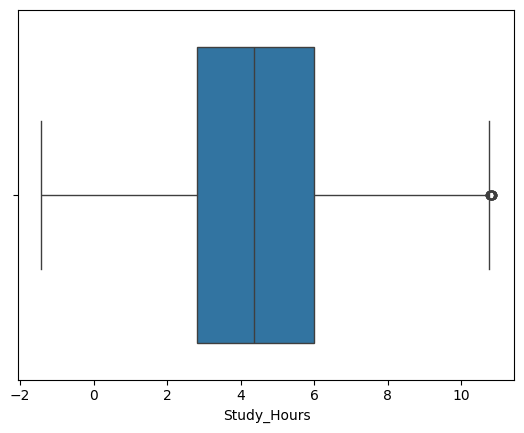

In [59]:
# plt.figure(figsize=(10,5))
sns.boxplot(x="Study_Hours",data=new_dataset)
plt.show()

Outliers Removed 😭😭😭😭😍😍😍

# Now Using Z-Score

In [45]:
dataset.head(3)


,Student_Type,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
0,school,6.868702,1.711722,3.176942,NaN,8.0,7.0,2.0,1
1,school,8.519088,3.251084,3.880787,93.978465,6.0,4.0,3.0,1
2,college,4.498770,6.306885,2.936172,64.421253,7.0,1.0,12.0,1


In [46]:
dataset.isnull().sum()

Student_Type          1252
Sleep_Hours           1333
Study_Hours              0
Social_Media_Hours    1312
Attendance            1305
Exam_Pressure         1270
Family_Support        1291
Month                 1314
Stress_Level             0
dtype: int64

In [47]:
dataset.describe()

,Sleep_Hours,Study_Hours,Social_Media_Hours,Attendance,Exam_Pressure,Family_Support,Month,Stress_Level
count,24167.000000,25500.000000,24188.000000,24195.000000,24230.000000,24209.000000,24186.000000,25500.000000
mean,6.458948,4.389501,3.555614,81.270961,5.369748,5.798298,6.500992,0.299882
std,1.504228,2.560179,1.901528,12.052045,2.394003,2.232371,3.455308,0.458215
min,2.008586,-1.433434,0.000040,-5.000000,1.000000,1.000000,1.000000,0.000000
25%,5.438360,2.820657,2.152249,73.738894,4.000000,4.000000,3.000000,0.000000
50%,6.542566,4.382555,3.500709,81.942959,5.000000,6.000000,6.000000,0.000000
75%,7.531571,6.034491,4.864312,90.106859,7.000000,7.000000,10.000000,1.000000
max,9.997527,22.444460,9.962134,120.000000,10.000000,10.000000,12.000000,1.000000


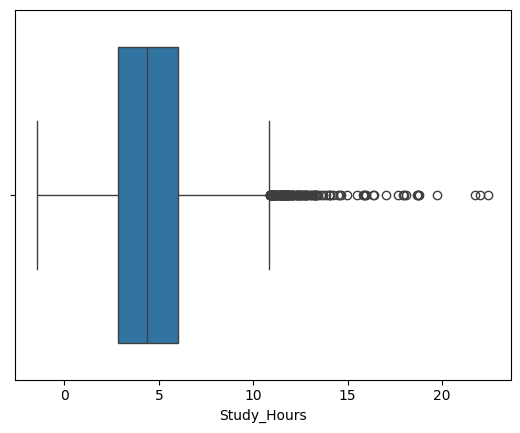

In [52]:
sns.boxplot(x=dataset["Study_Hours"],data=dataset)
plt.show()

C:\Users\SHAMSHER\AppData\Local\Temp\ipykernel_23244\3112419410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=dataset["Study_Hours"])


<Axes: ylabel='Density'>

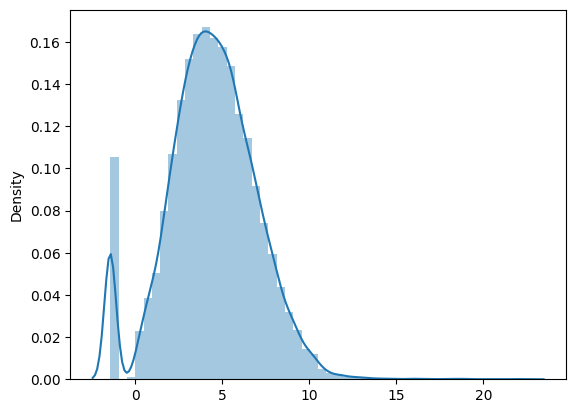

In [53]:
sns.distplot(x=dataset["Study_Hours"])

In [54]:
min_range = dataset["Study_Hours"].mean() - (3*dataset["Study_Hours"].std())
max_range = dataset["Study_Hours"].mean() + (3*dataset["Study_Hours"].std())
min_range , max_range

(np.float64(-3.291037140568293), np.float64(12.07003931889684))

In [56]:
new_data = dataset[dataset["Study_Hours"]<=max_range]

In [69]:
new_data.shape

(25434, 9)

<Axes: xlabel='Study_Hours'>

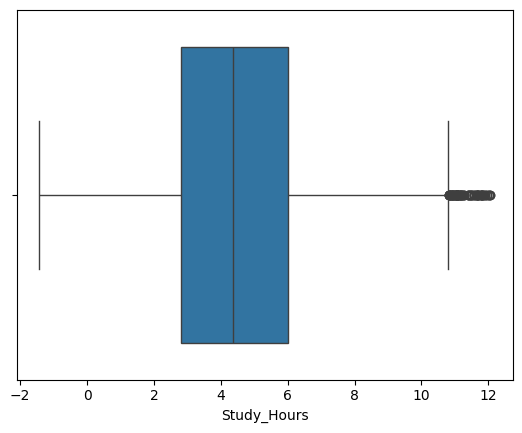

In [58]:
sns.boxplot(x="Study_Hours",data=new_data)

Outlier Removing using Standart Deviation

# Now Finding Z-Score

Formula ->
z_score = (data - mean)/std

In [62]:
z_score = (dataset["Study_Hours"] - dataset["Study_Hours"].mean())/(dataset["Study_Hours"].std())
z_score>3

0        False
1        False
2        False
3        False
4        False
         ...  
25495    False
25496    False
25497    False
25498    False
25499    False
Name: Study_Hours, Length: 25500, dtype: bool

In [63]:
dataset["z_score"] = z_score

In [ ]:
dataset.shape

(25500, 10)

In [75]:
dataset[dataset["z_score"]<3].shape

(25434, 10)